In [1]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd

In [2]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [3]:
claims = [
    "The Eiffel Tower is in Paris",
    "The Eiffel Tower is in London",
    "The Moon is made of cheese"
]

fact = "The Eiffel Tower is in Paris"

In [4]:
fact_embedding = model.encode([fact])

scores = []

for claim in claims:

    claim_embedding = model.encode([claim])

    similarity = cosine_similarity(
        claim_embedding,
        fact_embedding
    )[0][0]

    scores.append(similarity)

In [5]:
results = pd.DataFrame({
    "Claim": claims,
    "Similarity Score": scores
})

print(results)

                           Claim  Similarity Score
0   The Eiffel Tower is in Paris          1.000000
1  The Eiffel Tower is in London          0.865252
2     The Moon is made of cheese          0.086351


In [6]:
predictions = []

for score in scores:

    if score >= 0.80:
        predictions.append("SUPPORTED")

    elif score < 0.40:
        predictions.append("HALLUCINATION")

    else:
        predictions.append("UNCERTAIN")

In [7]:
results["Prediction"] = predictions

print(results)

                           Claim  Similarity Score     Prediction
0   The Eiffel Tower is in Paris          1.000000      SUPPORTED
1  The Eiffel Tower is in London          0.865252      SUPPORTED
2     The Moon is made of cheese          0.086351  HALLUCINATION


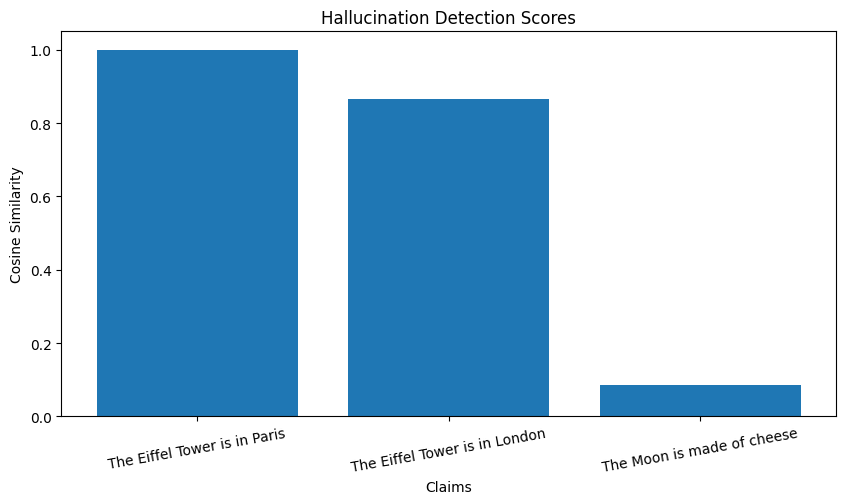

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.bar(claims, scores)

plt.title("Hallucination Detection Scores")

plt.xlabel("Claims")

plt.ylabel("Cosine Similarity")

plt.xticks(rotation=10)

plt.show()